# Layer-Wise Approximation Experiment

This notebook implements the advisor-note interpretation as a **surrogate approximation study**.

Core question:
- How simple a function can approximate the layer transition `h_l -> h_{l+1}`?
- Does the required surrogate complexity change with layer depth or model size?

Default setup in this notebook:
- use Hugging Face ImageNet examples
- approximate the **CLS token only** first
- fit a separate surrogate for each model and each layer
- compare `identity`, `linear`, `two-layer linear`, and `two-layer ReLU` surrogates

Notes:
- The two-layer linear surrogate is intentionally included because it was in the notes, even though it is still globally linear.
- This notebook is designed to be run incrementally. Nothing here has been executed automatically.

In [1]:
from copy import deepcopy
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Dict, List, Optional, Sequence
import gc

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from datasets import load_dataset
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm
from transformers import AutoImageProcessor, DeiTForImageClassificationWithTeacher, ViTForImageClassification

sns.set_theme(style="whitegrid")


def choose_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


device = choose_device()
print(f"Using device: {device}")


@dataclass(frozen=True)
class ModelSpec:
    name: str
    repo_id: str
    imagenet_top1: float
    imagenet_top5: float
    params: str
    is_distilled: bool = False


MODEL_SPECS: List[ModelSpec] = [
    ModelSpec("DeiT-tiny", "facebook/deit-tiny-patch16-224", 72.2, 91.1, "5M"),
    ModelSpec("DeiT-small", "facebook/deit-small-patch16-224", 79.9, 95.0, "22M"),
    ModelSpec("DeiT-base", "facebook/deit-base-patch16-224", 81.8, 95.6, "86M"),
    ModelSpec("DeiT-tiny distilled", "facebook/deit-tiny-distilled-patch16-224", 74.5, 91.9, "6M", True),
    ModelSpec("DeiT-small distilled", "facebook/deit-small-distilled-patch16-224", 81.2, 95.4, "22M", True),
    ModelSpec("DeiT-base distilled", "facebook/deit-base-distilled-patch16-224", 83.4, 96.5, "87M", True),
    ModelSpec("DeiT-base 384", "facebook/deit-base-patch16-384", 82.9, 96.2, "87M"),
    ModelSpec("DeiT-base distilled 384", "facebook/deit-base-distilled-patch16-384", 85.2, 97.2, "88M", True),
]


EXPERIMENT_CONFIG = {
    "dataset_name": "pouya-haghi/imagenet-1k",
    "split": "train",
    "max_samples": 10_000,
    "train_fraction": 0.8,
    "selected_model_names": [spec.name for spec in MODEL_SPECS],
    "extraction_batch_size": 8,
    "extraction_batch_size_384": 2,
    "surrogate_batch_size": 256,
    "surrogate_epochs": 20,
    "surrogate_lr": 1e-3,
    "surrogate_weight_decay": 1e-5,
    "width_multipliers": [2.0, 4.0],
    "nmse_threshold": 0.10,
    "seed": 42,
    "results_dir": "layer_approximation_results",
    "show_progress": True,
}

pd.DataFrame([asdict(spec) for spec in MODEL_SPECS])

Using device: cuda


,name,repo_id,imagenet_top1,imagenet_top5,params,is_distilled
0,DeiT-tiny,facebook/deit-tiny-patch16-224,72.2,91.1,5M,False
1,DeiT-small,facebook/deit-small-patch16-224,79.9,95.0,22M,False
2,DeiT-base,facebook/deit-base-patch16-224,81.8,95.6,86M,False
3,DeiT-tiny distilled,facebook/deit-tiny-distilled-patch16-224,74.5,91.9,6M,True
4,DeiT-small distilled,facebook/deit-small-distilled-patch16-224,81.2,95.4,22M,True
5,DeiT-base distilled,facebook/deit-base-distilled-patch16-224,83.4,96.5,87M,True
6,DeiT-base 384,facebook/deit-base-patch16-384,82.9,96.2,87M,False
7,DeiT-base distilled 384,facebook/deit-base-distilled-patch16-384,85.2,97.2,88M,True


In [2]:
def slugify(value: str) -> str:
    return value.lower().replace("-", "_").replace(" ", "_")


def select_model_specs(selected_names: Optional[Sequence[str]] = None) -> List[ModelSpec]:
    if not selected_names:
        return MODEL_SPECS

    selected_name_set = set(selected_names)
    selected = [spec for spec in MODEL_SPECS if spec.name in selected_name_set]
    missing = sorted(selected_name_set - {spec.name for spec in selected})
    if missing:
        raise ValueError(f"Unknown model names: {missing}")
    return selected


def get_model_class(spec: ModelSpec):
    if spec.is_distilled:
        return DeiTForImageClassificationWithTeacher
    return ViTForImageClassification


def load_model_and_processor(spec: ModelSpec):
    processor = AutoImageProcessor.from_pretrained(spec.repo_id, use_fast=True)
    model_cls = get_model_class(spec)
    model = model_cls.from_pretrained(spec.repo_id)
    model = model.to(device).eval()
    return model, processor


def get_extraction_batch_size(spec: ModelSpec, config: Dict) -> int:
    if "384" in spec.repo_id:
        return config.get("extraction_batch_size_384", config["extraction_batch_size"])
    return config["extraction_batch_size"]


def sample_dataset(dataset_split, max_samples: int, seed: int):
    total_samples = min(max_samples, len(dataset_split))
    shuffled = dataset_split.shuffle(seed=seed)
    return shuffled.select(range(total_samples))


def iter_image_batches(dataset_split, processor, batch_size: int, show_progress: bool = True):
    iterator = range(0, len(dataset_split), batch_size)
    if show_progress:
        iterator = tqdm(iterator, desc="Encoding images", leave=False)

    for start_idx in iterator:
        batch = dataset_split[start_idx : start_idx + batch_size]
        images = [image.convert("RGB") for image in batch["image"]]
        inputs = processor(images=images, return_tensors="pt")
        inputs = {key: value.to(device) for key, value in inputs.items()}
        yield inputs


@torch.inference_mode()
def collect_cls_hidden_states(model, processor, dataset_split, batch_size: int, show_progress: bool = True):
    layer_buffers: Optional[List[List[torch.Tensor]]] = None

    for inputs in iter_image_batches(dataset_split, processor, batch_size, show_progress=show_progress):
        outputs = model(**inputs, output_hidden_states=True)
        if outputs.hidden_states is None:
            raise ValueError("Model did not return hidden states. Check that `output_hidden_states=True` is supported.")

        cls_states = [hidden_state[:, 0, :].detach().to("cpu", dtype=torch.float32) for hidden_state in outputs.hidden_states]
        if layer_buffers is None:
            layer_buffers = [[] for _ in range(len(cls_states))]

        for layer_idx, cls_state in enumerate(cls_states):
            layer_buffers[layer_idx].append(cls_state)

        del outputs, cls_states, inputs
        if device.type == "cuda":
            torch.cuda.empty_cache()

    if layer_buffers is None:
        raise ValueError("No hidden states were collected.")

    return [torch.cat(chunks, dim=0) for chunks in layer_buffers]


def build_layer_transition_datasets(layer_states: List[torch.Tensor], train_fraction: float, seed: int):
    if len(layer_states) < 2:
        raise ValueError("Need at least two hidden-state tensors to build transitions.")

    num_examples = layer_states[0].shape[0]
    generator = torch.Generator().manual_seed(seed)
    permutation = torch.randperm(num_examples, generator=generator)
    train_size = int(num_examples * train_fraction)
    train_idx = permutation[:train_size]
    val_idx = permutation[train_size:]

    if len(val_idx) == 0:
        raise ValueError("Validation split is empty. Increase `max_samples` or reduce `train_fraction`.")

    layer_pairs = {}
    for layer_idx in range(len(layer_states) - 1):
        inputs = layer_states[layer_idx]
        targets = layer_states[layer_idx + 1]
        layer_pairs[layer_idx] = {
            "train_inputs": inputs[train_idx],
            "train_targets": targets[train_idx],
            "val_inputs": inputs[val_idx],
            "val_targets": targets[val_idx],
            "input_dim": inputs.shape[-1],
            "train_size": len(train_idx),
            "val_size": len(val_idx),
        }

    return layer_pairs


def cleanup_model(*objects) -> None:
    for obj in objects:
        del obj
    if device.type == "cuda":
        torch.cuda.empty_cache()
    gc.collect()

In [3]:
class IdentityApproximator(nn.Module):
    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        return inputs


class LinearApproximator(nn.Module):
    def __init__(self, input_dim: int):
        super().__init__()
        self.proj = nn.Linear(input_dim, input_dim)

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        return self.proj(inputs)


class TwoLayerApproximator(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, use_relu: bool):
        super().__init__()
        layers = [nn.Linear(input_dim, hidden_dim)]
        if use_relu:
            layers.append(nn.ReLU())
        layers.append(nn.Linear(hidden_dim, input_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        return self.net(inputs)


def parameter_count(module: nn.Module) -> int:
    return sum(parameter.numel() for parameter in module.parameters() if parameter.requires_grad)


def build_surrogate_specs(input_dim: int, width_multipliers: Sequence[float]):
    specs = [{"label": "identity", "kind": "identity", "hidden_dim": None}]
    specs.append({"label": "linear", "kind": "linear", "hidden_dim": None})

    for width_multiplier in width_multipliers:
        hidden_dim = max(int(round(input_dim * width_multiplier)), input_dim + 1)
        width_tag = str(width_multiplier).replace(".", "p")
        specs.append(
            {
                "label": f"two_layer_linear_x{width_tag}",
                "kind": "two_layer_linear",
                "hidden_dim": hidden_dim,
            }
        )
        specs.append(
            {
                "label": f"two_layer_relu_x{width_tag}",
                "kind": "two_layer_relu",
                "hidden_dim": hidden_dim,
            }
        )

    return specs


def build_surrogate(spec: Dict, input_dim: int) -> nn.Module:
    if spec["kind"] == "identity":
        return IdentityApproximator()
    if spec["kind"] == "linear":
        return LinearApproximator(input_dim)
    if spec["kind"] == "two_layer_linear":
        return TwoLayerApproximator(input_dim=input_dim, hidden_dim=spec["hidden_dim"], use_relu=False)
    if spec["kind"] == "two_layer_relu":
        return TwoLayerApproximator(input_dim=input_dim, hidden_dim=spec["hidden_dim"], use_relu=True)
    raise ValueError(f"Unsupported surrogate kind: {spec['kind']}")


def regression_metrics(predictions: torch.Tensor, targets: torch.Tensor) -> Dict[str, float]:
    residual = predictions - targets
    mse = residual.pow(2).mean()
    centered_targets = targets - targets.mean(dim=0, keepdim=True)
    target_variance = centered_targets.pow(2).mean().clamp_min(1e-12)
    nmse = mse / target_variance
    cosine = F.cosine_similarity(predictions, targets, dim=-1).mean()
    ss_res = residual.pow(2).sum()
    ss_tot = centered_targets.pow(2).sum().clamp_min(1e-12)
    r2 = 1.0 - (ss_res / ss_tot)

    return {
        "mse": float(mse.item()),
        "nmse": float(nmse.item()),
        "cosine_similarity": float(cosine.item()),
        "r2": float(r2.item()),
    }


@torch.inference_mode()
def predict_in_batches(module: nn.Module, inputs: torch.Tensor, batch_size: int) -> torch.Tensor:
    module.eval()
    predictions = []
    for start_idx in range(0, len(inputs), batch_size):
        batch_inputs = inputs[start_idx : start_idx + batch_size].to(device)
        batch_predictions = module(batch_inputs).detach().to("cpu", dtype=torch.float32)
        predictions.append(batch_predictions)
    return torch.cat(predictions, dim=0)


def train_surrogate(module: nn.Module, train_inputs: torch.Tensor, train_targets: torch.Tensor, val_inputs: torch.Tensor, val_targets: torch.Tensor, config: Dict):
    if parameter_count(module) == 0:
        return {"best_val_nmse": regression_metrics(val_inputs, val_targets)["nmse"]}

    train_loader = DataLoader(
        TensorDataset(train_inputs, train_targets),
        batch_size=config["surrogate_batch_size"],
        shuffle=True,
    )
    optimizer = torch.optim.AdamW(
        module.parameters(),
        lr=config["surrogate_lr"],
        weight_decay=config["surrogate_weight_decay"],
    )
    loss_fn = nn.MSELoss()

    best_state = None
    best_val_nmse = float("inf")
    history = []
    module = module.to(device)

    for epoch_idx in range(config["surrogate_epochs"]):
        module.train()
        running_loss = 0.0
        seen_examples = 0

        for batch_inputs, batch_targets in train_loader:
            batch_inputs = batch_inputs.to(device)
            batch_targets = batch_targets.to(device)

            optimizer.zero_grad(set_to_none=True)
            batch_predictions = module(batch_inputs)
            loss = loss_fn(batch_predictions, batch_targets)
            loss.backward()
            optimizer.step()

            batch_size = batch_inputs.shape[0]
            running_loss += float(loss.item()) * batch_size
            seen_examples += batch_size

        val_predictions = predict_in_batches(module, val_inputs, config["surrogate_batch_size"])
        val_metrics = regression_metrics(val_predictions, val_targets)
        train_loss = running_loss / max(seen_examples, 1)
        history.append(
            {
                "epoch": epoch_idx + 1,
                "train_loss": train_loss,
                "val_nmse": val_metrics["nmse"],
            }
        )

        if val_metrics["nmse"] < best_val_nmse:
            best_val_nmse = val_metrics["nmse"]
            best_state = deepcopy({key: value.detach().cpu() for key, value in module.state_dict().items()})

    if best_state is not None:
        module.load_state_dict(best_state)

    return {
        "best_val_nmse": best_val_nmse,
        "history": pd.DataFrame(history),
    }


def fit_and_score_surrogate(layer_pair: Dict, surrogate_spec: Dict, config: Dict) -> Dict[str, float]:
    module = build_surrogate(surrogate_spec, layer_pair["input_dim"])
    train_info = train_surrogate(
        module,
        layer_pair["train_inputs"],
        layer_pair["train_targets"],
        layer_pair["val_inputs"],
        layer_pair["val_targets"],
        config,
    )

    train_predictions = predict_in_batches(module, layer_pair["train_inputs"], config["surrogate_batch_size"])
    val_predictions = predict_in_batches(module, layer_pair["val_inputs"], config["surrogate_batch_size"])
    train_metrics = regression_metrics(train_predictions, layer_pair["train_targets"])
    val_metrics = regression_metrics(val_predictions, layer_pair["val_targets"])

    result = {
        "surrogate_label": surrogate_spec["label"],
        "surrogate_kind": surrogate_spec["kind"],
        "hidden_dim": surrogate_spec["hidden_dim"],
        "param_count": parameter_count(module),
        "train_size": layer_pair["train_size"],
        "val_size": layer_pair["val_size"],
        "best_val_nmse": train_info["best_val_nmse"],
    }
    result.update({f"train_{key}": value for key, value in train_metrics.items()})
    result.update({f"val_{key}": value for key, value in val_metrics.items()})
    return result

In [4]:
def summarize_best_surrogates(results_df: pd.DataFrame, threshold: Optional[float] = None, metric: str = "val_nmse") -> pd.DataFrame:
    best_rows = []
    for (model_name, layer), frame in results_df.groupby(["model_name", "layer"]):
        by_complexity = frame.sort_values(["param_count", metric, "surrogate_label"])
        if threshold is not None:
            threshold_hits = by_complexity[by_complexity[metric] <= threshold]
            if not threshold_hits.empty:
                best_rows.append(threshold_hits.iloc[0].to_dict())
                continue
        best_rows.append(frame.sort_values([metric, "param_count"]).iloc[0].to_dict())
    return pd.DataFrame(best_rows)


def run_layer_approximation_for_spec(spec: ModelSpec, dataset_split, config: Dict) -> pd.DataFrame:
    print(f"Running layer approximation for {spec.name}...")
    sampled_dataset = sample_dataset(dataset_split, config["max_samples"], config["seed"])
    model, processor = load_model_and_processor(spec)
    layer_states = collect_cls_hidden_states(
        model,
        processor,
        sampled_dataset,
        batch_size=get_extraction_batch_size(spec, config),
        show_progress=config["show_progress"],
    )
    layer_pairs = build_layer_transition_datasets(layer_states, config["train_fraction"], config["seed"])

    rows = []
    surrogate_specs = build_surrogate_specs(layer_states[0].shape[-1], config["width_multipliers"])
    layer_iterator = sorted(layer_pairs.items())
    if config["show_progress"]:
        layer_iterator = tqdm(layer_iterator, desc=f"Fitting surrogates for {spec.name}", leave=False)

    try:
        for layer_idx, layer_pair in layer_iterator:
            for surrogate_spec in surrogate_specs:
                row = fit_and_score_surrogate(layer_pair, surrogate_spec, config)
                row.update(
                    {
                        "model_name": spec.name,
                        "repo_id": spec.repo_id,
                        "model_params": spec.params,
                        "imagenet_top1": spec.imagenet_top1,
                        "imagenet_top5": spec.imagenet_top5,
                        "is_distilled": spec.is_distilled,
                        "layer": layer_idx,
                    }
                )
                rows.append(row)
    finally:
        cleanup_model(model, processor, layer_states)

    return pd.DataFrame(rows)


def run_layer_approximation_suite(model_specs: Sequence[ModelSpec], dataset_split, config: Dict):
    results_dir = Path(config["results_dir"])
    results_dir.mkdir(parents=True, exist_ok=True)

    frames = []
    for spec in model_specs:
        frame = run_layer_approximation_for_spec(spec, dataset_split, config)
        frame.to_csv(results_dir / f"{slugify(spec.name)}_layer_approximation.csv", index=False)
        frames.append(frame)

    results_df = pd.concat(frames, ignore_index=True)
    best_surrogates_df = summarize_best_surrogates(
        results_df,
        threshold=config.get("nmse_threshold"),
        metric="val_nmse",
    )
    results_df.to_csv(results_dir / "layer_approximation_all_models.csv", index=False)
    best_surrogates_df.to_csv(results_dir / "layer_approximation_best_surrogates.csv", index=False)
    return results_df, best_surrogates_df


def plot_layerwise_metric(results_df: pd.DataFrame, model_name: str, metric: str = "val_nmse"):
    plot_df = results_df[results_df["model_name"] == model_name].copy()
    plt.figure(figsize=(12, 5))
    sns.lineplot(data=plot_df, x="layer", y=metric, hue="surrogate_label", marker="o")
    plt.title(f"{model_name}: layer-wise {metric}")
    plt.xlabel("Layer")
    plt.ylabel(metric)
    plt.legend(title="Surrogate", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


def plot_best_complexity(best_surrogates_df: pd.DataFrame, metric: str = "val_nmse"):
    plt.figure(figsize=(12, 5))
    sns.scatterplot(
        data=best_surrogates_df,
        x="layer",
        y="param_count",
        hue="model_name",
        style="surrogate_label",
        s=120,
    )
    plt.yscale("log")
    plt.title(f"Minimum surrogate complexity chosen per layer ({metric} threshold)")
    plt.xlabel("Layer")
    plt.ylabel("Parameter count (log scale)")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

In [5]:
selected_specs = select_model_specs(EXPERIMENT_CONFIG["selected_model_names"])
dataset_split = load_dataset(
    EXPERIMENT_CONFIG["dataset_name"],
    split=EXPERIMENT_CONFIG["split"],
)

print(
    f"Loaded {len(dataset_split):,} examples from "
    f"{EXPERIMENT_CONFIG['dataset_name']}[{EXPERIMENT_CONFIG['split']!r}]"
)
pd.DataFrame([asdict(spec) for spec in selected_specs])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md:   0%|          | 0.00/314 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/43.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1024 [00:00<?, ? examples/s]

Loaded 1,024 examples from pouya-haghi/imagenet-1k['train']


,name,repo_id,imagenet_top1,imagenet_top5,params,is_distilled
0,DeiT-tiny,facebook/deit-tiny-patch16-224,72.2,91.1,5M,False
1,DeiT-small,facebook/deit-small-patch16-224,79.9,95.0,22M,False
2,DeiT-base,facebook/deit-base-patch16-224,81.8,95.6,86M,False
3,DeiT-tiny distilled,facebook/deit-tiny-distilled-patch16-224,74.5,91.9,6M,True
4,DeiT-small distilled,facebook/deit-small-distilled-patch16-224,81.2,95.4,22M,True
5,DeiT-base distilled,facebook/deit-base-distilled-patch16-224,83.4,96.5,87M,True
6,DeiT-base 384,facebook/deit-base-patch16-384,82.9,96.2,87M,False
7,DeiT-base distilled 384,facebook/deit-base-distilled-patch16-384,85.2,97.2,88M,True


In [9]:
# Recommended first pass:
# 1. Start with a single model, for example:
# debug_config = {**EXPERIMENT_CONFIG, "selected_model_names": ["DeiT-tiny"], "max_samples": 2_000}
# debug_specs = select_model_specs(debug_config["selected_model_names"])
# debug_results_df, debug_best_df = run_layer_approximation_suite(debug_specs, dataset_split, debug_config)
#
# 2. Scale to the full comparison after the pipeline looks reasonable:
results_df, best_surrogates_df = run_layer_approximation_suite(selected_specs, dataset_split, EXPERIMENT_CONFIG)


Running layer approximation for DeiT-tiny...


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Encoding images:   0%|          | 0/128 [00:00<?, ?it/s]

Fitting surrogates for DeiT-tiny:   0%|          | 0/12 [00:00<?, ?it/s]

Running layer approximation for DeiT-small...


...

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/351M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

Encoding images:   0%|          | 0/512 [00:00<?, ?it/s]

Fitting surrogates for DeiT-base distilled 384:   0%|          | 0/12 [00:00<?, ?it/s]

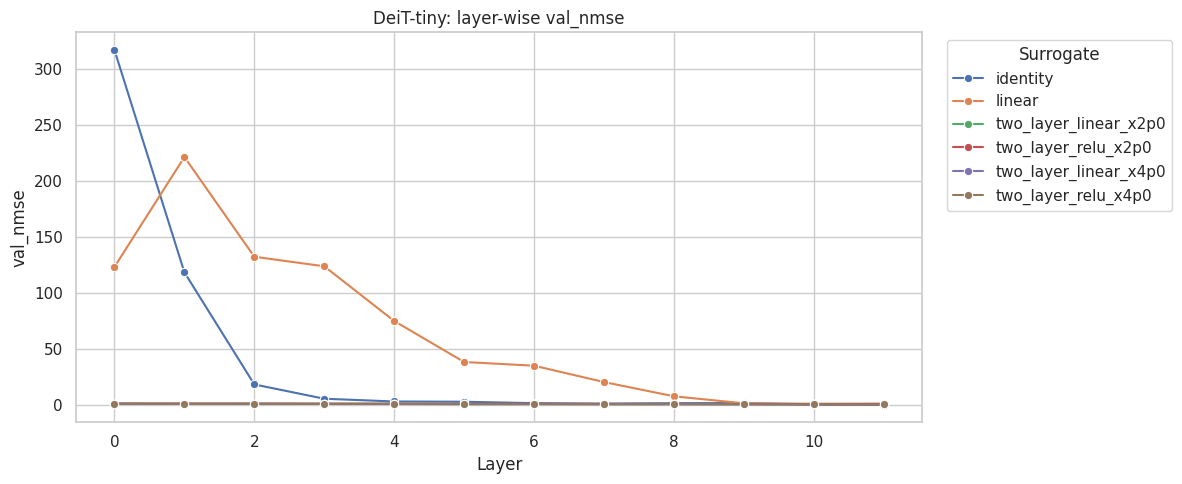

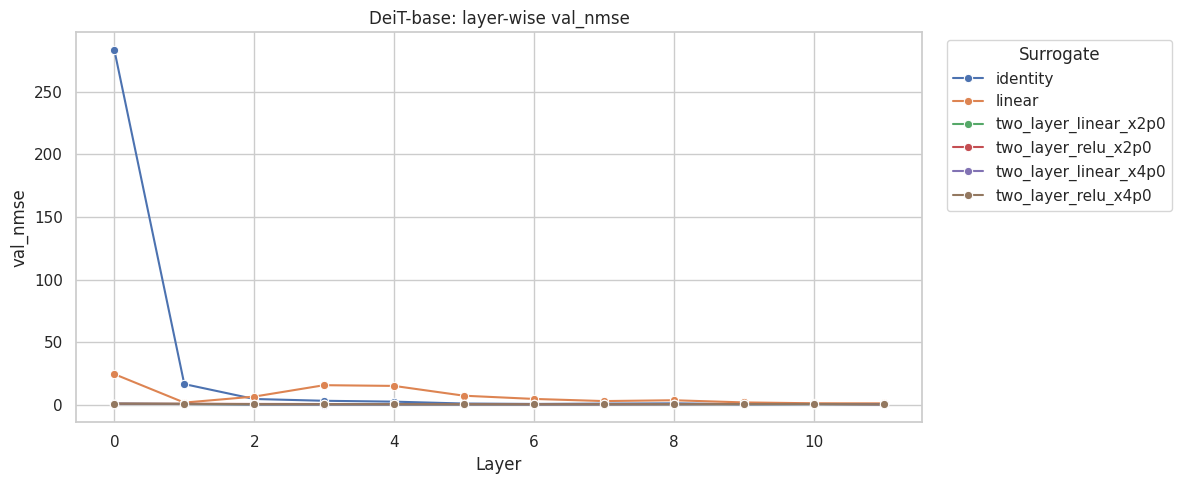

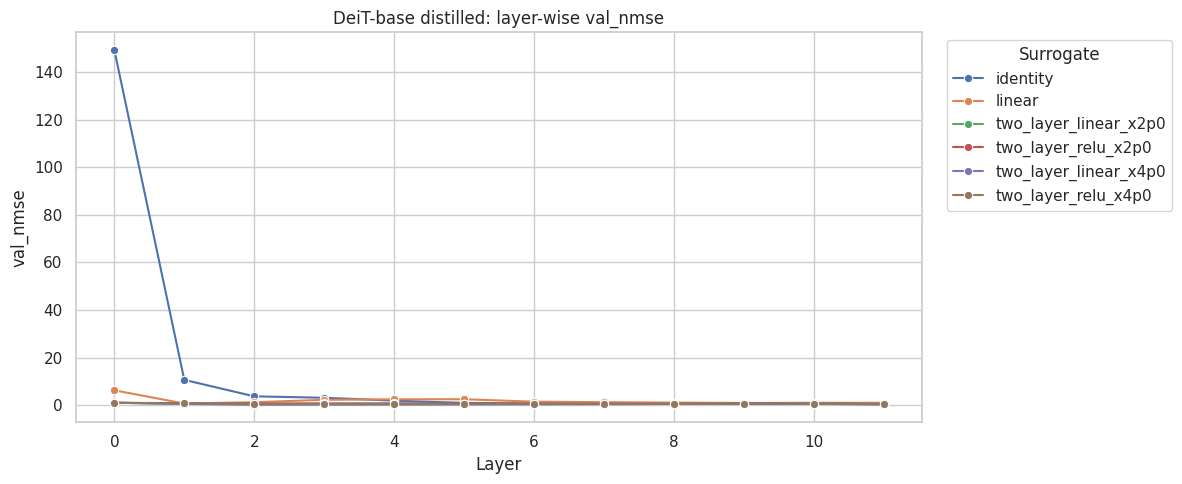

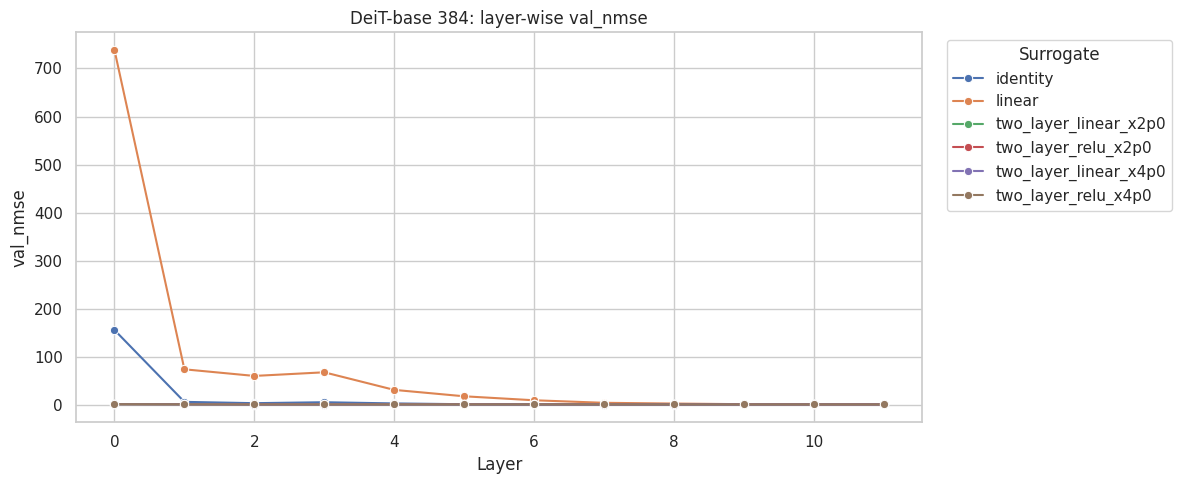

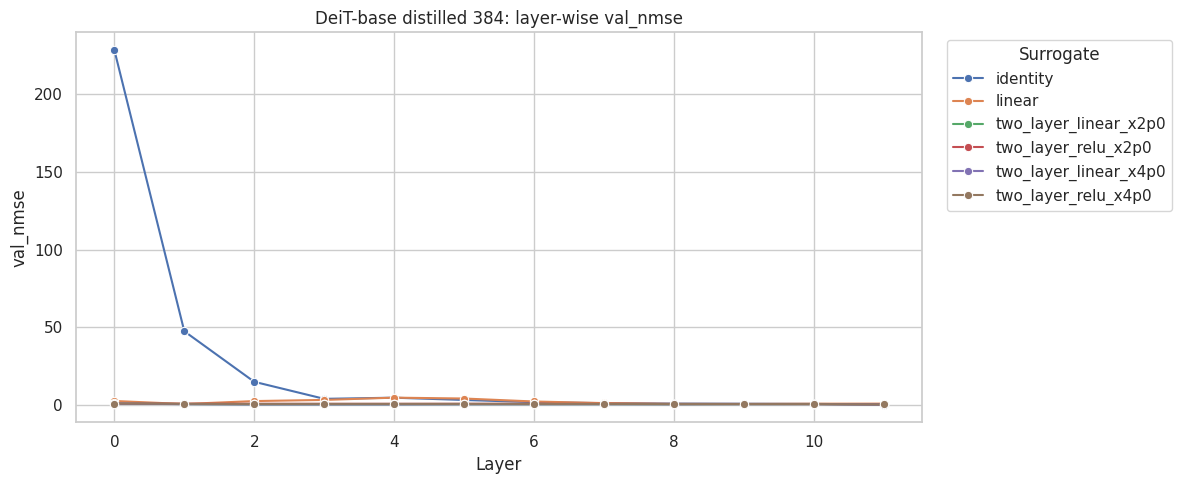

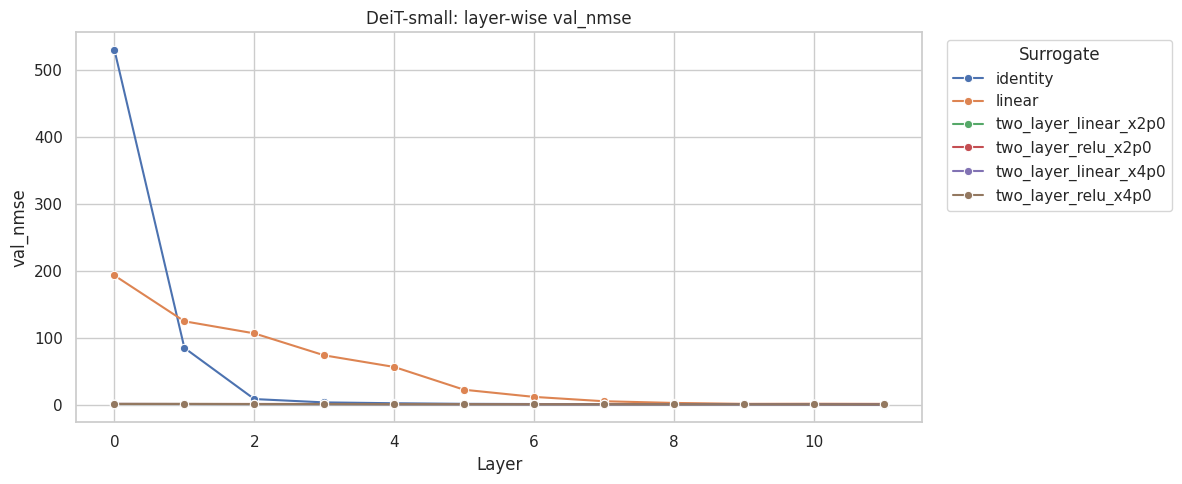

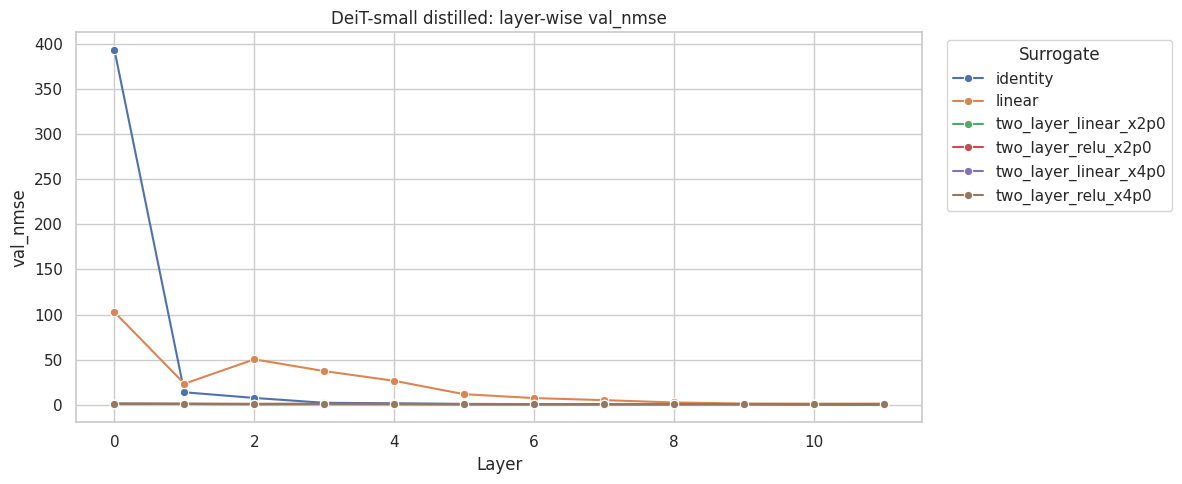

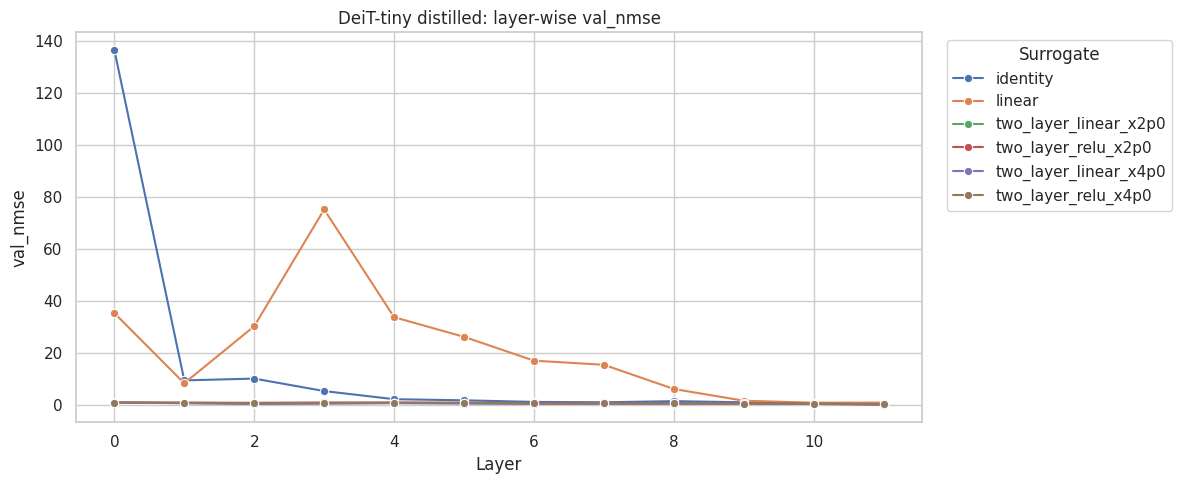

In [10]:
plot_layerwise_metric(results_df, model_name="DeiT-tiny", metric="val_nmse")
plot_layerwise_metric(results_df, model_name="DeiT-base", metric="val_nmse")
plot_layerwise_metric(results_df, model_name="DeiT-base distilled", metric="val_nmse")
plot_layerwise_metric(results_df, model_name="DeiT-base 384", metric="val_nmse")
plot_layerwise_metric(results_df, model_name="DeiT-base distilled 384", metric="val_nmse")
plot_layerwise_metric(results_df, model_name="DeiT-small", metric="val_nmse")
plot_layerwise_metric(results_df, model_name="DeiT-small distilled", metric="val_nmse")
plot_layerwise_metric(results_df, model_name="DeiT-tiny distilled", metric="val_nmse")

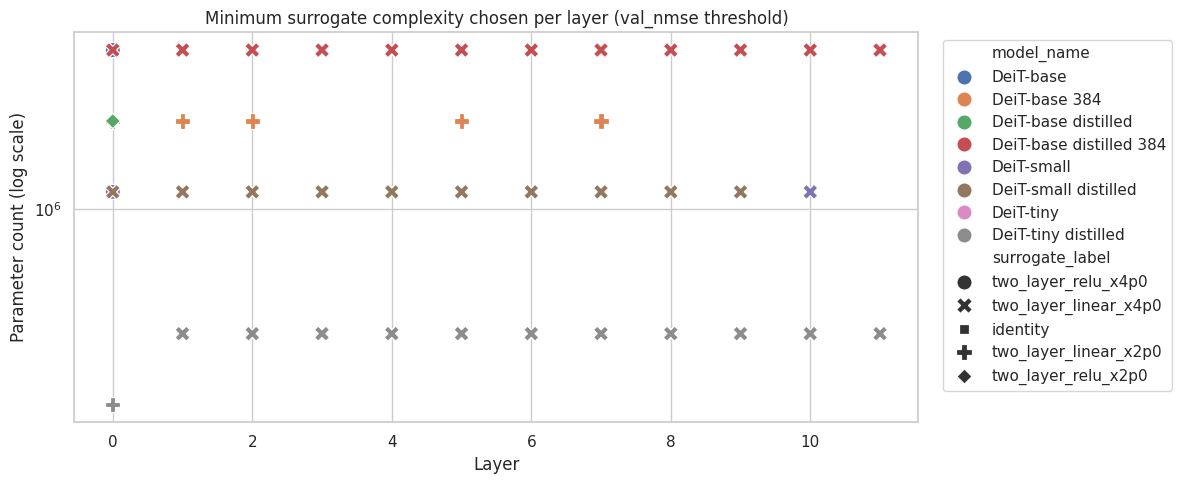

In [11]:
plot_best_complexity(best_surrogates_df)